<p style="font-size:24px;text-align:center;">Horizontal Zeros</p>

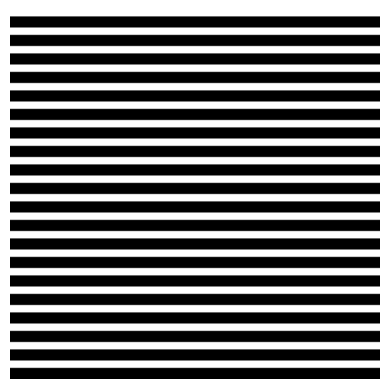

In [42]:
import matplotlib.pyplot as plt

def h_zeros(h, w):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    for i in range(0, h, 10):
        for j in range(w):
            for k in range(4): 
                img[i+k, j] = [255, 255, 255]
    return img

img = h_zeros(200, 200)

plt.imshow(img)
plt.axis('off')
plt.show()

<p style="font-size:24px;text-align:center;">Horizontal Zeros with sine function</p>

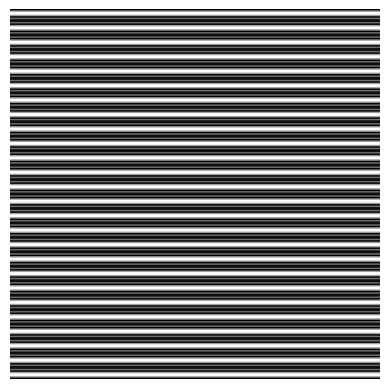

In [5]:
import matplotlib.pyplot as plt
import numpy as np 

def h_sin_zeros():
    x = np.arange(256)
    y = np.sin(2 * np.pi * (x / 10))
    img_list = []
    for i in range(256):
        for j in range(256):
            img_list.append([y[i] * 255])
    image = np.array(img_list, dtype=np.uint8).reshape(256, 256)
    return image

img = h_sin_zeros()

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

<p style="font-size:24px;text-align:center;">Vertical Zeros</p>

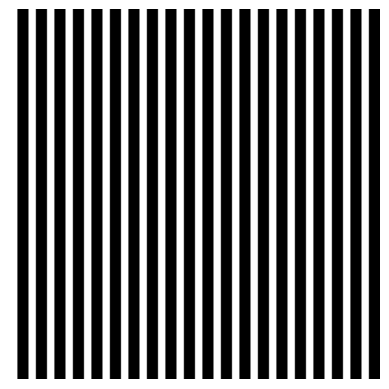

In [43]:
import matplotlib.pyplot as plt

def v_zeros(h, w):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    for i in range(h):
        for j in range(0, w, 10):
            for k in range(4): 
                img[i, j+k] = [255, 255, 255]
    return img
    
img = v_zeros(200, 200)
plt.imshow(img)
plt.axis('off')
plt.show()


<p style="font-size:24px;text-align:center;">Vertical Zeros with sine function</p>

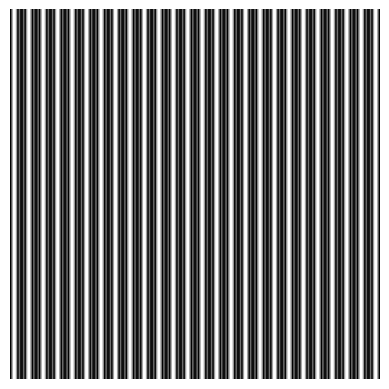

In [9]:
import matplotlib.pyplot as plt

def v_sin_zeros():
    x = np.arange(256)
    y = np.sin(2 * np.pi * (x / 10))
    img_list = []
    for i in range(256):
        for j in range(256):
            img_list.append([y[j] * 255])
    image = np.array(img_list, dtype=np.uint8).reshape(256, 256)
    return image

img = v_sin_zeros()

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

<p style="font-size:24px;text-align:center;">Hatched Zeros</p>

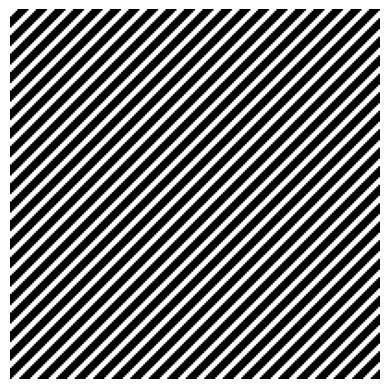

In [44]:
import cv2
import matplotlib.pyplot as plt
 
def hatched_zeros(h, w):
    img = np.zeros((h, w, 3), dtype=np.uint8)  
    for i in range(h):
        for j in range(w):
            if np.mod(i, 10) == 0 and np.mod(j, 10) == 0 and i == j:
                for k in range(4):
                    cv2.line(img, (i+k, 0), (0, j+k), (255, 255, 255))
                    cv2.line(img, (i+k, w), (h, j+k), (255, 255, 255))
    return img

img = hatched_zeros(200, 200)                
plt.imshow(img)
plt.axis('off')
plt.show()
                   

<p style="font-size:24px;text-align:center;">Hatched Zeros with sine function</p>

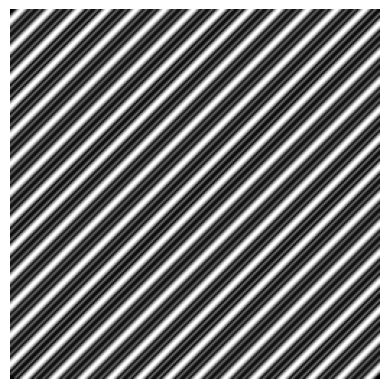

In [13]:
import matplotlib.pyplot as plt
import cv2

def hatched_sin_zeros(theta):
    x = np.arange(256)
    y = np.sin(2 * np.pi * (x / 10))
    img_list = []
    for i in range(256):
        for j in range(256):
            img_list.append([y[j] * 255])
    image = np.array(img_list, dtype=np.uint8).reshape(256, 256)
    center = (image.shape[1] / 2, image.shape[0] / 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, theta, 1.4)
    rotated_img = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))
    return rotated_img

img = hatched_sin_zeros(-45)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

<p style="font-size:24px;text-align:center;">Hatched Circle</p>

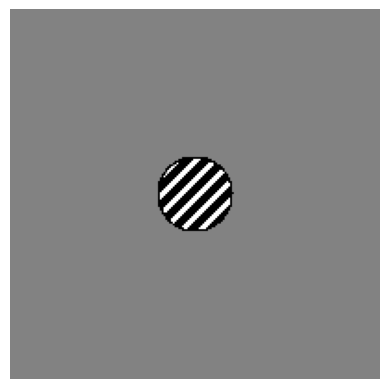

In [52]:
import math
import matplotlib.pyplot as plt

def TurnOnPixel(x, y, image):
    image[y, x] = [0, 0, 0]

def drawCircle(img, x, y, r):
    alpha = int(x / 2)
    beta = int(y / 2)
    lowBoundX = beta - r
    highBoundX = beta + r
    step = 0.005
    edgeCircle = []
    X_values = np.arange(lowBoundX, highBoundX, step)
    for X in X_values:
        Y1 = int(beta + math.sqrt(r * r - (X - alpha) * (X - alpha)))
        Y2 = int(beta - math.sqrt(r * r - (X - alpha) * (X - alpha)))
        edgeCircle.append([int(X), Y1])
        edgeCircle.append([int(X), Y2])
        TurnOnPixel(int(X), Y1, img)  # Convert X to int for column index
        TurnOnPixel(int(X), Y2, img)  # Convert X to int for column index
    return img, alpha, beta, edgeCircle


def hatched_circle(h, w, r):
    img = hatched_zeros(h, w)  
    
    # Call the function to draw the circle on the image
    cc, alpha, beta, edgeData = drawCircle(img, w, h, r)
    
    # Modify pixels outside the circular region to gray
    for i in range(h):
        for j in range(w):
            if i < beta - r or i > beta + r:
                cc[i, j] = [130, 130, 130]
            if j < alpha - r or j > alpha + r:
                cc[i, j] = [130, 130, 130]
    
    # Loop over the pixel area within the bounds of the circle
    for i in range(beta-r, beta+r+1):
        for j in range(alpha-r, alpha+r+1):
            p1 = np.array([i, j])
            p2 = np.array([beta, alpha])
            dist = np.linalg.norm(p1 - p2)
            
            # If the pixel is outside the circle, set it to gray
            if dist >= r:
                if [i, j] not in edgeData:
                    cc[i, j] = [130, 130, 130]
    return cc

img = hatched_circle(200, 200, 20)

plt.imshow(img)
plt.axis('off')
plt.show()

<p style="font-size:24px;text-align:center;">Hatched Circle with sine function</p>

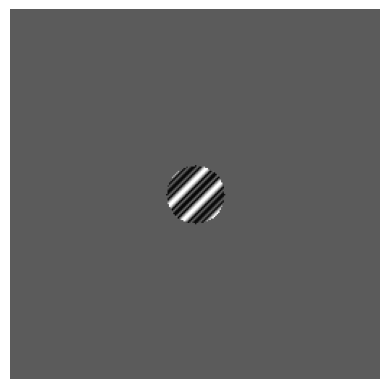

In [14]:
import matplotlib.pyplot as plt
import cv2

def hatched_sin_circle(theta, r):
    x = np.arange(256)
    y = np.sin(2 * np.pi * (x / 10))
    img_list = []
    for i in range(256):
        for j in range(256):
            img_list.append([y[j] * 255])
    image = np.array(img_list, dtype=np.uint8).reshape(256, 256)
    center = (image.shape[1] / 2, image.shape[0] / 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, theta, 1.4)
    rotated_img = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))

    alpha = int(image.shape[0] / 2)
    beta = int(image.shape[1] / 2)

    for i in range(256):
        for j in range(256):
            dist = (i - alpha)**2 + (j - beta)**2
            if dist > r**2:
                rotated_img[i, j] = 90
    return rotated_img


img = hatched_sin_circle(-45, 20)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

<p style="font-size:24px;text-align:center;">White Circle</p>

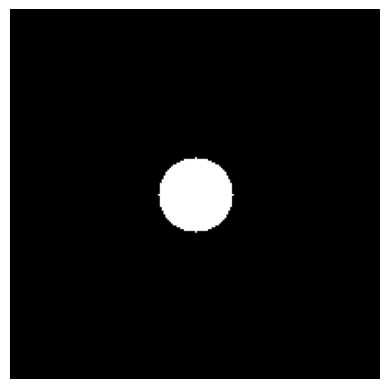

In [50]:
import matplotlib.pyplot as plt

def whiteCircle(h, w, radius):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    alpha = w / 2
    beta = h / 2
 
    # Define the bounds of the circle's pixel range for further processing
    minBoundj = int(beta - radius)
    maxBoundj = int(beta + radius)
    minBoundi = int(alpha - radius)
    maxBoundi = int(alpha + radius)
    
    # Loop over the pixel area within the bounds of the circle
    for i in range(minBoundi, maxBoundi+1):
        for j in range(minBoundj, maxBoundj+1):
            dist = (i - beta)**2 + (j - alpha)**2
            if dist <= radius**2:
                img[i, j] = [255, 255, 255]
                
    return img

c = whiteCircle(200, 200, 20)

plt.imshow(c)
plt.axis('off')
plt.show()

<p style="font-size:24px;text-align:center;">White Square</p>

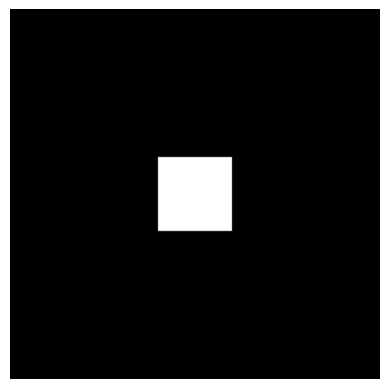

In [49]:
import numpy as np
import matplotlib.pyplot as plt
        
def whiteSquare(h, w):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    alpha = int(w / 2)
    beta = int(h / 2)
    d = 20
    for i in range(beta-d, beta+d):
        for j in range(alpha-d, alpha+d):
            img[i, j] = [255, 255, 255]
    return img 
        
img = whiteSquare(200, 200)        
        
plt.imshow(img)
plt.axis('off')
plt.show()